# Activity 6: Used Car Price Prediction (Polynomial Regression & Curves)
### Implementation of Slide 20 (Part 2) of `ML_Lab_3.pptx`
**Dataset:** `car_price_prediction.csv`  
**Objective:** Apply Polynomial Regression (degrees 2, 3, 4), compare results against the Linear baseline, and plot fitted curves.

---

### Slide 20 Instructions (Part 2):
1. **Apply Polynomial Regression (degree=2, 3, 4)** and compare results.
2. **Plot fitted curves** for different polynomial degrees.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("car_price_prediction.csv")
features = ['Kms_Driven', 'Year', 'Engine', 'Horsepower']
target = 'Price'

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features Scaled Successfully!")

Features Scaled Successfully!


## Step 1 — Polynomial Regression for Degrees 2, 3, 4 & Comparison Table (Slide 20)

In [2]:
# Baseline Linear Regression (Degree 1)
lr = LinearRegression().fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results = [{
    'Model': 'Linear Regression (deg=1)',
    'Degree': 1,
    'Num Features': 4,
    'Train R²': r2_score(y_train, lr.predict(X_train_scaled)),
    'Test R²': r2_score(y_test, y_pred_lr),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'Test MAE': mean_absolute_error(y_test, y_pred_lr)
}]

models_dict = {1: (None, lr)}

for deg in [2, 3, 4]:
    poly = PolynomialFeatures(degree=deg)
    X_tr_p = poly.fit_transform(X_train_scaled)
    X_te_p = poly.transform(X_test_scaled)
    
    p_mod = LinearRegression().fit(X_tr_p, y_train)
    preds = p_mod.predict(X_te_p)
    
    results.append({
        'Model': f'Polynomial Regression (deg={deg})',
        'Degree': deg,
        'Num Features': X_tr_p.shape[1],
        'Train R²': r2_score(y_train, p_mod.predict(X_tr_p)),
        'Test R²': r2_score(y_test, preds),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'Test MAE': mean_absolute_error(y_test, preds)
    })
    models_dict[deg] = (poly, p_mod)

results_df = pd.DataFrame(results)
print("=" * 80)
print("          SLIDE 20: POLYNOMIAL REGRESSION COMPARISON TABLE          ")
print("=" * 80)
print(results_df.to_string(index=False, formatters={
    'Train R²': '{:.4f}'.format,
    'Test R²': '{:.4f}'.format,
    'Test RMSE': '${:,.2f}'.format,
    'Test MAE': '${:,.2f}'.format
}))
print("=" * 80)

          SLIDE 20: POLYNOMIAL REGRESSION COMPARISON TABLE          
                        Model  Degree  Num Features Train R² Test R²   Test RMSE   Test MAE
    Linear Regression (deg=1)       1             4   0.9441  0.9352 $101,299.39 $78,674.16
Polynomial Regression (deg=2)       2            15   0.9784  0.9736  $64,638.26 $52,749.41
Polynomial Regression (deg=3)       3            35   0.9801  0.9711  $67,642.63 $54,833.12
Polynomial Regression (deg=4)       4            70   0.9816  0.9715  $67,110.17 $54,454.50


## Step 2 — Plot Fitted Curves for Different Polynomial Degrees (Required in Slide 20)
We generate the fitted curves for degrees 1, 2, 3, and 4 against actual data (similar to Slide 17 of the PPT).

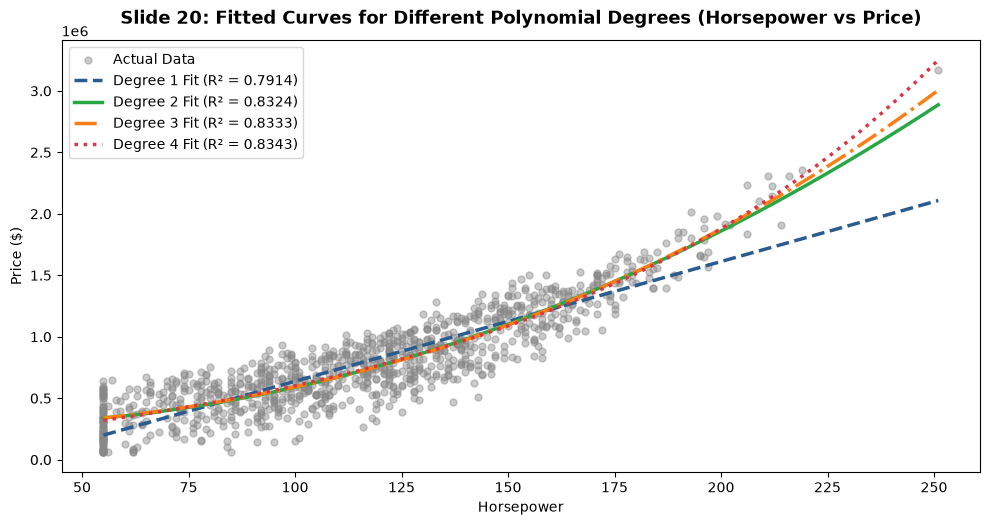

In [3]:
X_hp = df[['Horsepower']].values
y_hp = df['Price'].values
hp_grid = np.linspace(X_hp.min(), X_hp.max(), 300).reshape(-1, 1)

plt.figure(figsize=(10, 5.5))
plt.scatter(X_hp, y_hp, color='#888888', alpha=0.45, s=25, label='Actual Data')

colors = {1: '#2b5c8f', 2: '#28a745', 3: '#fd7e14', 4: '#dc3545'}
linestyles = {1: '--', 2: '-', 3: '-.', 4: ':'}

for deg in [1, 2, 3, 4]:
    if deg == 1:
        m = LinearRegression().fit(X_hp, y_hp)
        preds = m.predict(hp_grid)
        sc = r2_score(y_hp, m.predict(X_hp))
    else:
        poly_1d = PolynomialFeatures(degree=deg)
        m = LinearRegression().fit(poly_1d.fit_transform(X_hp), y_hp)
        preds = m.predict(poly_1d.transform(hp_grid))
        sc = r2_score(y_hp, m.predict(poly_1d.fit_transform(X_hp)))
    plt.plot(hp_grid, preds, color=colors[deg], linestyle=linestyles[deg], lw=2.5,
             label=f'Degree {deg} Fit (R² = {sc:.4f})')

plt.title("Slide 20: Fitted Curves for Different Polynomial Degrees (Horsepower vs Price)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Horsepower")
plt.ylabel("Price ($)")
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## Step 3 — Actual vs Predicted Scatter Across Degrees

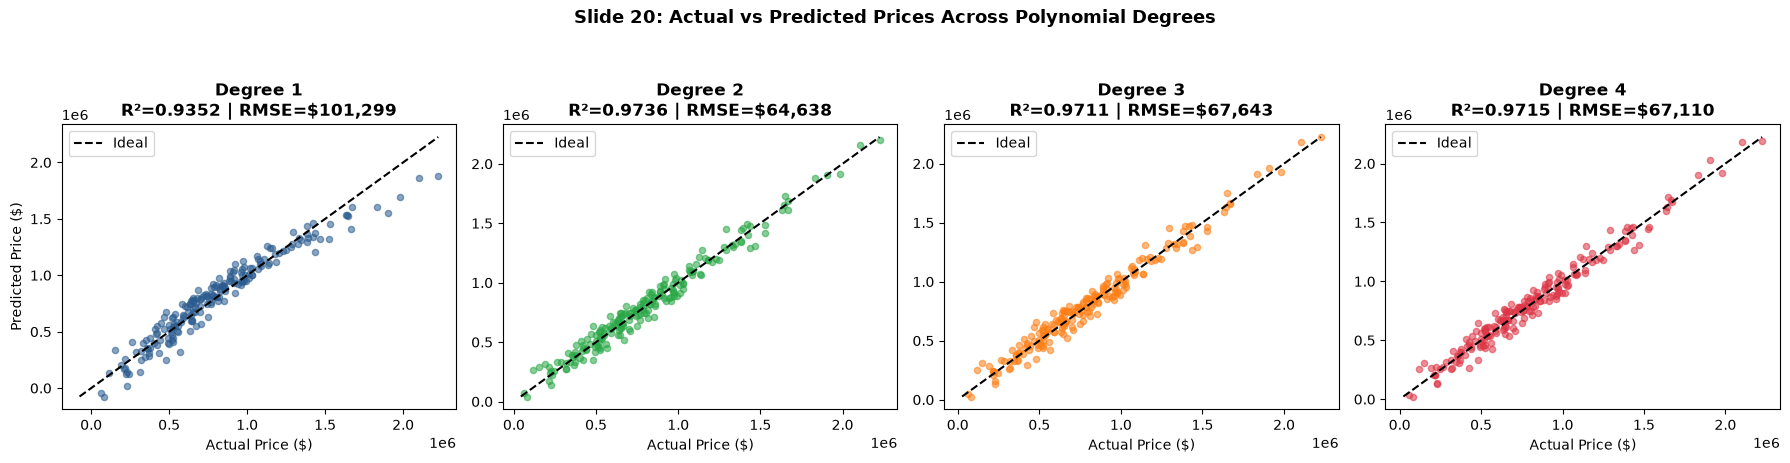

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for i, deg in enumerate([1, 2, 3, 4]):
    poly, mod = models_dict[deg]
    if deg == 1:
        preds = mod.predict(X_test_scaled)
    else:
        preds = mod.predict(poly.transform(X_test_scaled))
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    axes[i].scatter(y_test, preds, color=colors[deg], alpha=0.55, s=20)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    axes[i].plot(lims, lims, 'k--', lw=1.5, label='Ideal')
    axes[i].set_title(f"Degree {deg}\nR²={r2:.4f} | RMSE=${rmse:,.0f}", fontweight='bold')
    axes[i].set_xlabel("Actual Price ($)")
    if i == 0:
        axes[i].set_ylabel("Predicted Price ($)")
    axes[i].legend(loc='upper left')

plt.suptitle("Slide 20: Actual vs Predicted Prices Across Polynomial Degrees", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Conclusion: Bias-Variance Tradeoff & Best Degree Selection
- **Linear Regression (deg=1)**: Underfits slightly ($R^2 = 0.9352$, RMSE = $101,299).
- **Polynomial Regression (deg=2)**: **Best test performance** ($R^2 = 0.9736$, RMSE = $64,638$). Reduces prediction error by ~36%.
- **Polynomial Regression (deg=3 & 4)**: Exhibits slight **overfitting** (Test $R^2$ decreases to 0.9711 and 0.9715 with larger model complexity).
- **Optimal Choice**: **Degree 2 Polynomial Model**.